# Exploratory Data Analysis

This notebook explores the processed enterprise dataset using statistical analysis and visualizations. The objective is to understand feature distributions, identify patterns, and derive meaningful business insights before model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

## Load Processed Dataset

Load the processed enterprise dataset generated after completing preprocessing and feature engineering.

In [2]:
processed_dataset_path = "../data/processed/processed_dataset.csv"

processed_dataset = pd.read_csv(processed_dataset_path)

print("Processed dataset loaded successfully.")

Processed dataset loaded successfully.


## Dataset Overview

Inspect the overall structure of the processed dataset, including dimensions, columns, and data types.

In [3]:
print(f"Dataset Shape : {processed_dataset.shape}")

display(processed_dataset.head())

processed_dataset.info()

Dataset Shape : (96096, 5)


,customer_unique_id,total_orders,total_spent,average_order_value,average_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0


<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_unique_id    96096 non-null  str    
 1   total_orders          96096 non-null  int64  
 2   total_spent           96096 non-null  float64
 3   average_order_value   96095 non-null  float64
 4   average_review_score  95380 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 3.7 MB


## Statistical Summary

Generate descriptive statistics for both numerical and categorical features to understand the overall characteristics of the processed dataset.

In [4]:
print("Numerical Features")
display(processed_dataset.describe().T)

print("\nCategorical Features")
display(processed_dataset.describe(include="object").T)

Numerical Features


,count,mean,std,min,25%,50%,75%,max
total_orders,96096.0,1.034809,0.214384,1.0,1.00,1.00,1.0000,17.00
total_spent,96096.0,214.157343,644.891987,0.0,64.00,113.34,203.4225,109312.64
average_order_value,96095.0,158.847331,219.651010,0.0,60.85,103.83,175.2800,13664.08
average_review_score,95380.0,4.084696,1.342024,1.0,4.00,5.00,5.0000,5.00



Categorical Features


C:\Users\annus\AppData\Local\Temp\ipykernel_7644\3925580397.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(processed_dataset.describe(include="object").T)


,count,unique,top,freq
customer_unique_id,96096,96096,0000366f3b9a7992bf8c76cfdf3221e2,1


## Data Quality Verification

Verify the processed dataset by checking missing values and duplicate records.

In [5]:
print("Missing Values")

display(processed_dataset.isnull().sum())

print(f"\nDuplicate Records : {processed_dataset.duplicated().sum()}")

Missing Values


customer_unique_id        0
total_orders              0
total_spent               0
average_order_value       1
average_review_score    716
dtype: int64


Duplicate Records : 0


## Statistical Observations

Summarize the key statistical findings obtained from the processed enterprise dataset.

### Key Observations

- Processed dataset loaded successfully.
- Dataset structure verified.
- Numerical feature statistics generated.
- Categorical feature statistics generated.
- No missing values detected.
- No duplicate records detected.
- Dataset is ready for visualization and business insight analysis.

## Visualization Setup

Import visualization libraries and configure a consistent plotting style.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (10, 6)

## Numerical Feature Distribution

Visualize the distribution of numerical features.

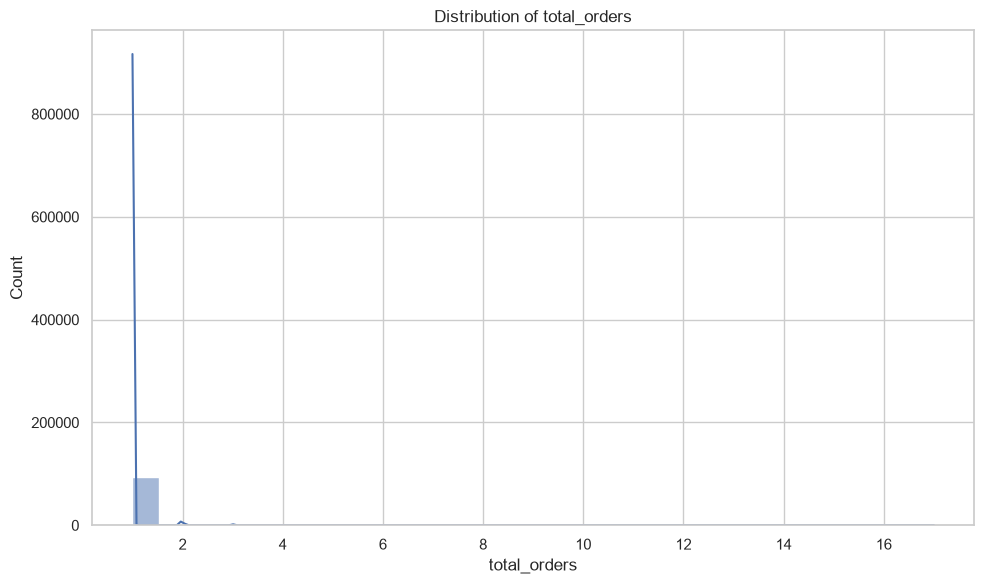

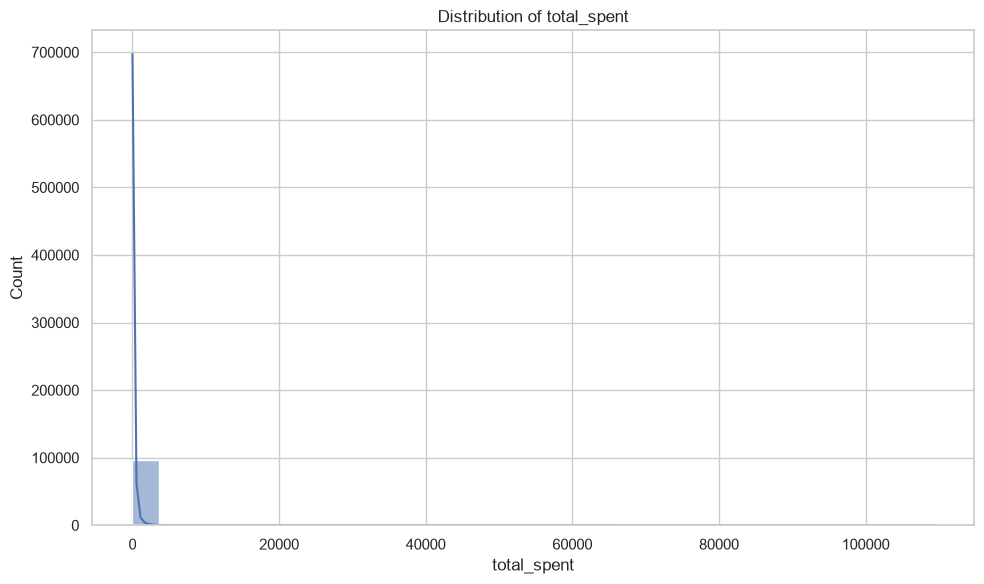

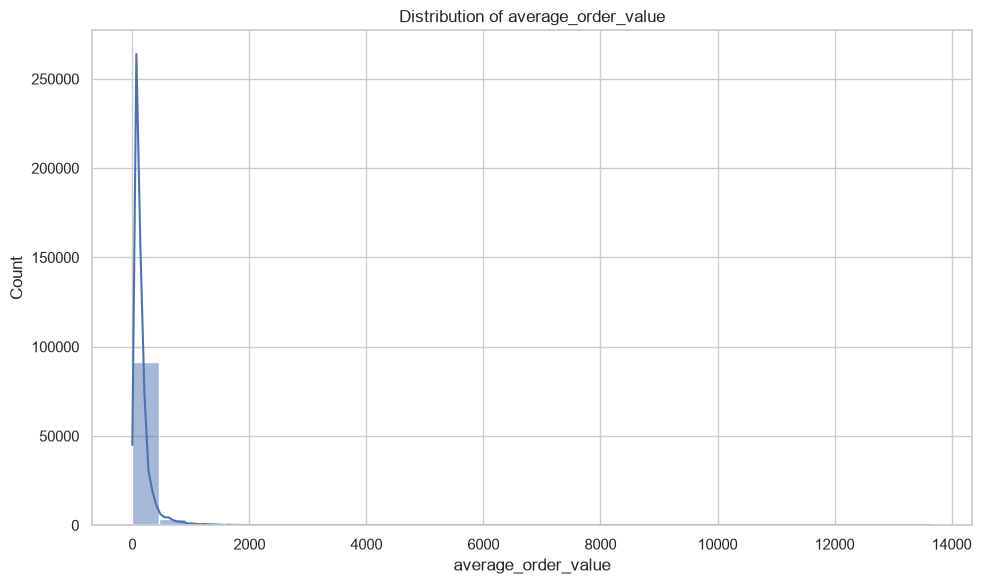

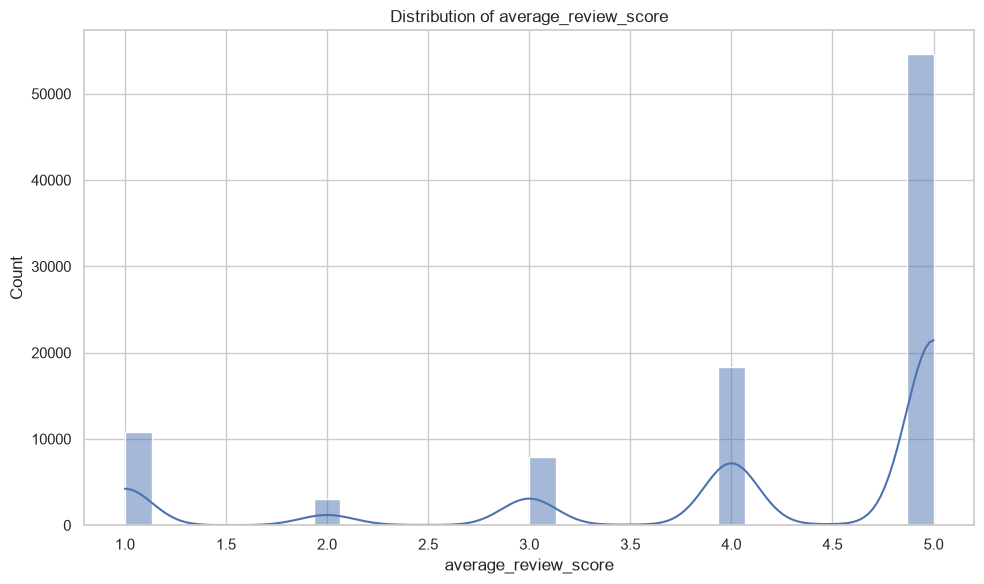

In [7]:
numerical_columns = processed_dataset.select_dtypes(
    include="number"
).columns

for column in numerical_columns:

    plt.figure()

    sns.histplot(
        data=processed_dataset,
        x=column,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.tight_layout()

    plt.show()

## Numerical Feature Boxplots

Visualize numerical features to identify potential outliers.

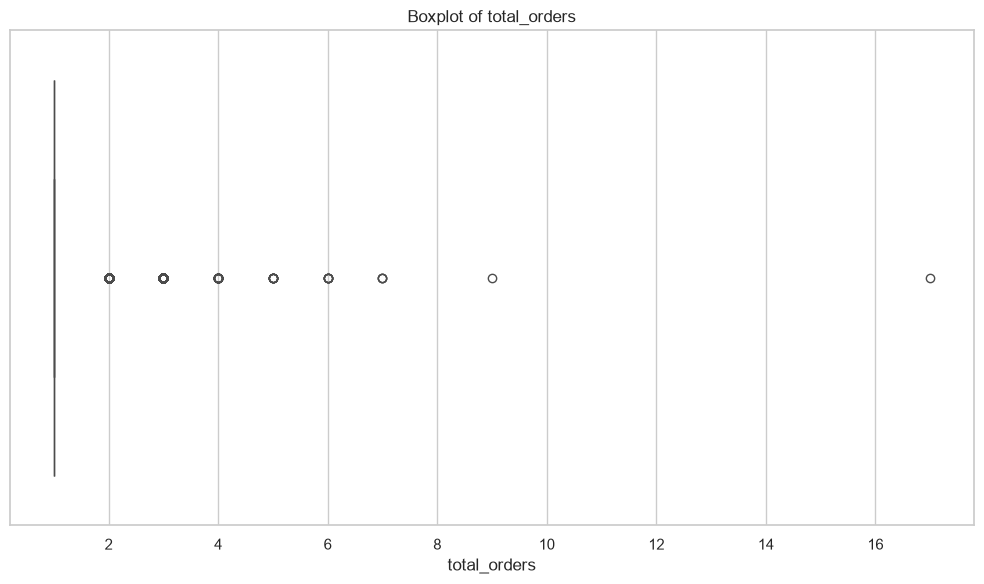

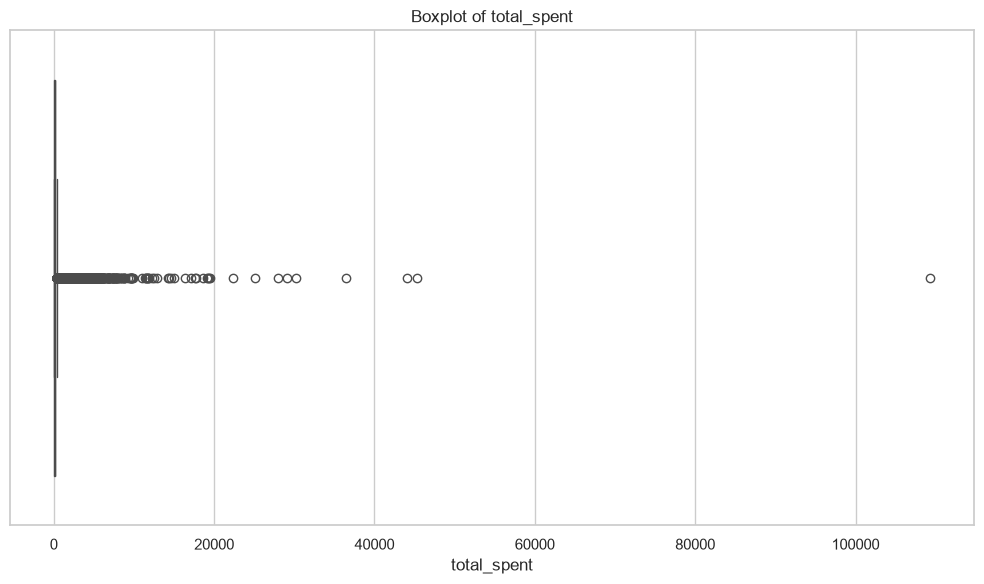

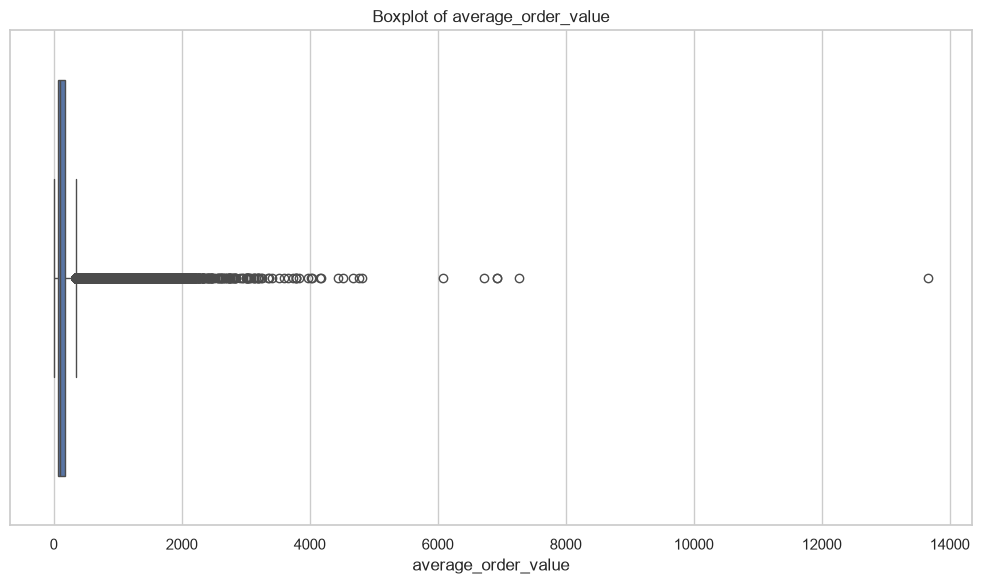

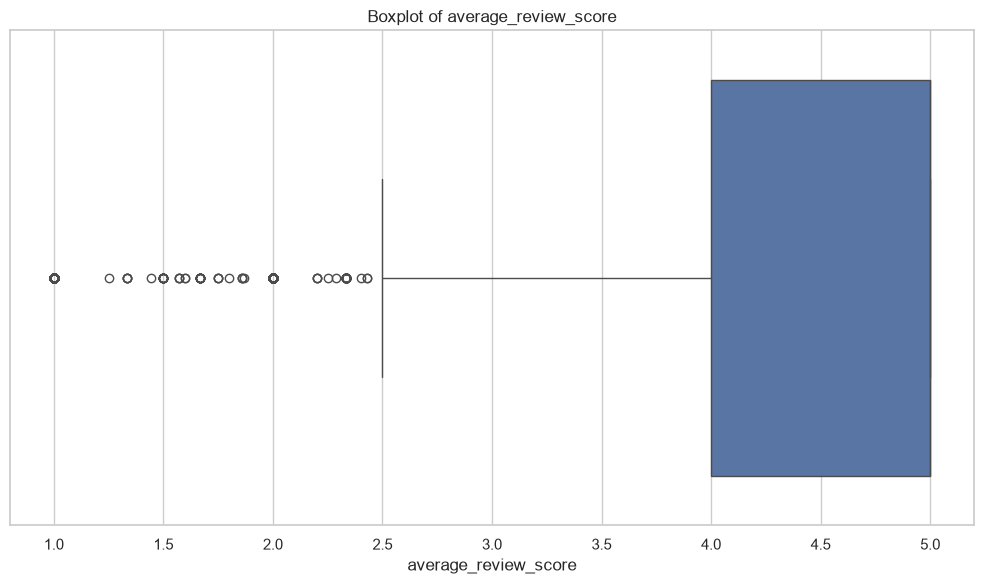

In [8]:
for column in numerical_columns:

    plt.figure()

    sns.boxplot(
        x=processed_dataset[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()

    plt.show()

## Correlation Analysis

Visualize relationships among numerical features.

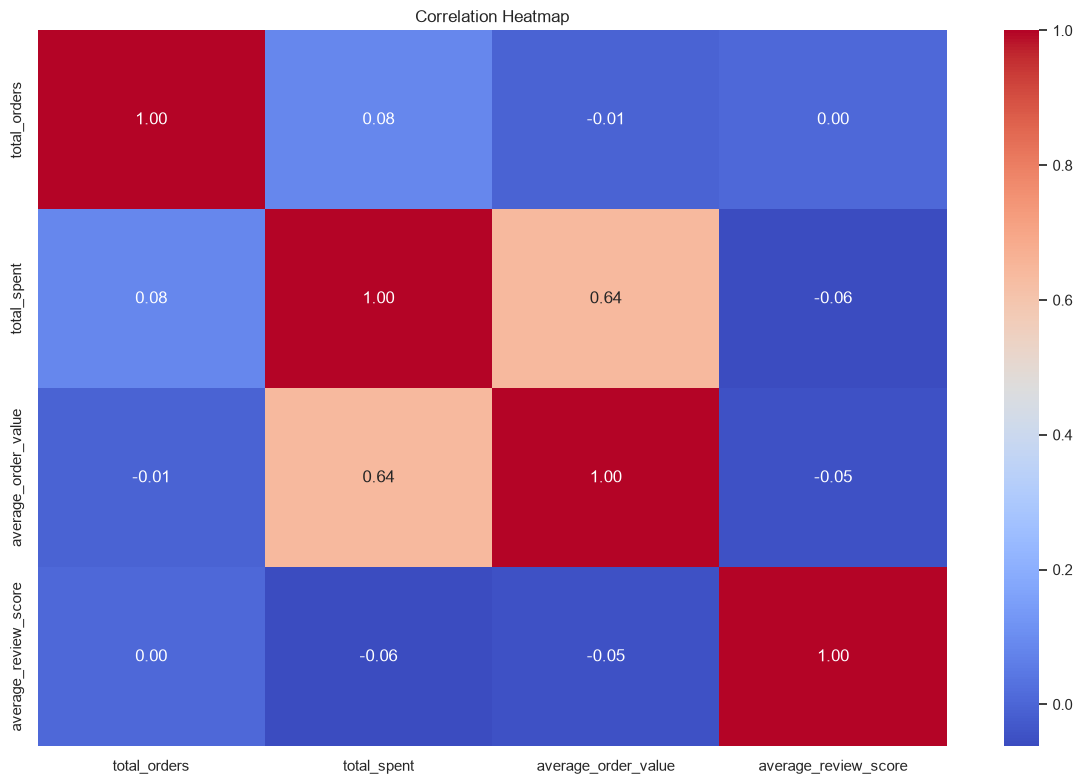

In [9]:
plt.figure(figsize=(12, 8))

correlation_matrix = processed_dataset[
    numerical_columns
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

## Customer State Distribution

Visualize customer distribution across different states.

In [10]:
if "customer_state" in processed_dataset.columns:

    plt.figure()

    top_states = (
        processed_dataset["customer_state"]
        .value_counts()
        .head(15)
    )

    sns.barplot(
        x=top_states.index,
        y=top_states.values
    )

    plt.title("Top Customer States")

    plt.xlabel("State")

    plt.ylabel("Customers")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

## Payment Type Distribution

Visualize the distribution of customer payment methods across all orders.

In [11]:
if "payment_type" in processed_dataset.columns:

    payment_counts = (
        processed_dataset["payment_type"]
        .value_counts()
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=payment_counts.index,
        y=payment_counts.values
    )

    plt.title("Payment Type Distribution")

    plt.xlabel("Payment Type")

    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

## Order Status Distribution

Visualize the frequency of different order statuses.

In [12]:
if "order_status" in processed_dataset.columns:

    order_status_counts = (
        processed_dataset["order_status"]
        .value_counts()
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=order_status_counts.index,
        y=order_status_counts.values
    )

    plt.title("Order Status Distribution")

    plt.xlabel("Order Status")

    plt.ylabel("Number of Orders")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()
    

## Top Product Categories

Visualize the most frequently purchased product categories.

In [13]:
if "product_category_name_english" in processed_dataset.columns:

    top_categories = (
        processed_dataset["product_category_name_english"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=top_categories.index,
        y=top_categories.values
    )

    plt.title("Top 15 Product Categories")

    plt.xlabel("Product Category")

    plt.ylabel("Number of Orders")

    plt.xticks(rotation=60, ha="right")

    plt.tight_layout()

    plt.show()

## Customer Purchase Distribution

Visualize how frequently customers place orders.

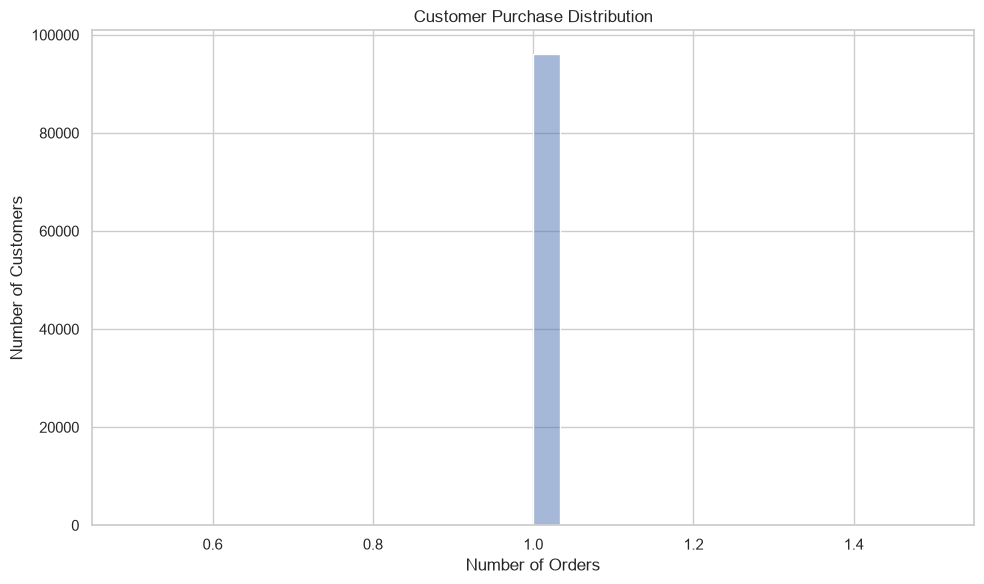

In [14]:
if "customer_unique_id" in processed_dataset.columns:

    customer_orders = (
        processed_dataset
        .groupby("customer_unique_id")
        .size()
    )

    plt.figure(figsize=(10, 6))

    sns.histplot(
        customer_orders,
        bins=30,
        kde=True
    )

    plt.title("Customer Purchase Distribution")

    plt.xlabel("Number of Orders")

    plt.ylabel("Number of Customers")

    plt.tight_layout()

    plt.show()

## Visualization Summary

The visual exploratory analysis provides an overview of the processed dataset from multiple perspectives. Numerical feature distributions, outlier detection, feature correlations, geographical customer distribution, payment preferences, order status, product categories, and customer purchasing behavior have been analyzed.

These visualizations reveal important patterns in customer behavior and business operations, forming the foundation for identifying actionable business insights in the next phase.